# Modelagem supervisionada — alfabetização

Prever se o aluno será **alfabetizado** (`alfabetizado` ∈ {0, 1}). É um problema de **classificação binária**.

Este notebook narra a pipeline do Scikit-learn. A execução completa e reproduzível está em `python scripts/run_modeling.py`.


## Candidatos

| Papel | Modelo | Por quê |
|-------|--------|---------|
| Favorito (performance) | Random Forest | não linearidades e interações territoriais / socioeconômicas; SHAP |
| Favorito (explicabilidade) | Regressão logística | citado no enunciado; odds ratio para gestores |
| Baseline | Dummy | piso: classe majoritária (~53,6% de acurácia, ROC AUC 0,500) |
| Didático | Árvore de decisão | regras visíveis |
| Didático | KNN | exige escala + one-hot |

Critério: maior ROC AUC na CV agrupada; empate (< 0,5 pp) → logística.


In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import GOLD_TABLE, GOLD_YEAR, IMAGES_DIR, RANDOM_STATE, SAMPLE_N, TARGET_COL
from src.preprocessing.features import build_model_frame, feature_lists, xy_groups
from src.preprocessing.load_s3 import load_gold_sample_cached
from src.modeling.split import grouped_holdout, overlap_municipalities, random_holdout
from src.evaluation.leakage import compare_random_vs_grouped
from src.evaluation.metrics import classification_metrics, predict_scores

print(f"tabela={GOLD_TABLE} ano={GOLD_YEAR} SAMPLE_N={SAMPLE_N} seed={RANDOM_STATE}")


tabela=alunos_features ano=2024 SAMPLE_N=300000 seed=42


## Dados

Amostra aleatória cacheada de `ano=2024`. `build_model_frame` remove constantes/redundâncias e cria `gap_meta`. `nivel_alfabetizacao` fica fora do X.


In [2]:
raw = load_gold_sample_cached(n=SAMPLE_N, year=GOLD_YEAR, random_state=RANDOM_STATE)
frame = build_model_frame(raw)
X, y, groups = xy_groups(frame)
numeric, low, high = feature_lists(frame)
print(frame.shape, "features", X.shape[1])
print("num", numeric)
print("low", low)
print("high", high)
print(y.value_counts(normalize=True).round(4))
print("municipios", groups.nunique())


(300000, 33) features 18
num ['lag1_taxa_alfabetizacao', 'lag1_media_portugues', 'lag1_uf_taxa_alfabetizacao', 'lag1_uf_media_portugues', 'meta_alfabetizacao_2024', 'uf_meta_alfabetizacao_2024', 'populacao', 'pib_per_capita', 'ivs', 'ivs_infraestrutura_urbana', 'ivs_capital_humano', 'ivs_renda_trabalho', 'capital_uf', 'amazonia_legal', 'gap_meta']
low ['rede', 'nome_regiao', 'sigla_uf']
high []
alfabetizado
1    0.5215
0    0.4785
Name: proportion, dtype: float64
municipios 5491


## Data leakage

Features preditivas são municipais. Split aleatório coloca o mesmo município nos dois lados.


In [3]:
leak = compare_random_vs_grouped(X, y, groups)
display(pd.Series(leak))
Xtr_r, Xte_r, ytr_r, yte_r, gtr_r, gte_r = random_holdout(X, y, groups)
Xtr, Xte, ytr, yte, gtr, gte = grouped_holdout(X, y, groups)
print("overlap aleatório", overlap_municipalities(gtr_r, gte_r))
print("overlap agrupado", overlap_municipalities(gtr, gte))


random_split_roc_auc             0.657118
grouped_split_roc_auc            0.670646
auc_inflation                   -0.013528
random_municipio_overlap      4854.000000
grouped_municipio_overlap        0.000000
n_municipios_train_grouped    4392.000000
n_municipios_test_grouped     1099.000000
dtype: float64

overlap aleatório 4854


overlap agrupado 0


## Pipeline único

- Numéricas: imputação mediana + `StandardScaler`.
- Categóricas (`rede`, região, UF): `DESCONHECIDO` + One-Hot.
- Mesmo preprocessamento para logística, árvores e KNN.

Tudo dentro de `Pipeline` + `ColumnTransformer`.


In [4]:
from src.modeling.preprocessing import build_preprocessor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

prep = build_preprocessor(numeric, low, high)
pipe = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=1000))])
pipe


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

## Treino e validação

`scripts/run_modeling.py` treina Dummy, Logística, Árvore, Random Forest e KNN com `RandomizedSearchCV` e `StratifiedGroupKFold`.

Métricas e figuras já geradas pelo script:


In [5]:
from pathlib import Path
import json
from IPython.display import Image, Markdown

metrics_path = ROOT / "reports" / "model_metrics.json"
if metrics_path.exists():
    metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    print("champion:", metrics.get("champion"))
    print("melhores hiperparâmetros:", metrics.get("best_params"))
    display(pd.DataFrame(metrics.get("holdout", [])).round(4))
else:
    print("Rode: python scripts/run_modeling.py")


champion: random_forest
melhores hiperparâmetros: {'clf__n_estimators': 80, 'clf__min_samples_leaf': 80, 'clf__max_features': 'sqrt', 'clf__max_depth': 16, 'clf__class_weight': 'balanced_subsample'}


,model,roc_auc,pr_auc,f1,recall,precision,brier,cv_roc_auc
0,dummy,0.5000,0.5365,0.6983,1.0000,0.5365,0.4635,NaN
1,logistic,0.6707,0.7032,0.6403,0.6228,0.6588,0.2266,0.6443
2,tree,0.6634,0.6846,0.6694,0.7229,0.6233,0.2277,0.6455
3,random_forest,0.6726,0.7052,0.6599,0.6754,0.6450,0.2258,0.6527
4,knn,0.6427,0.6716,0.6627,0.7140,0.6182,0.2352,0.6215


**Comparação de modelos** — `images/model_compare_auc.png`

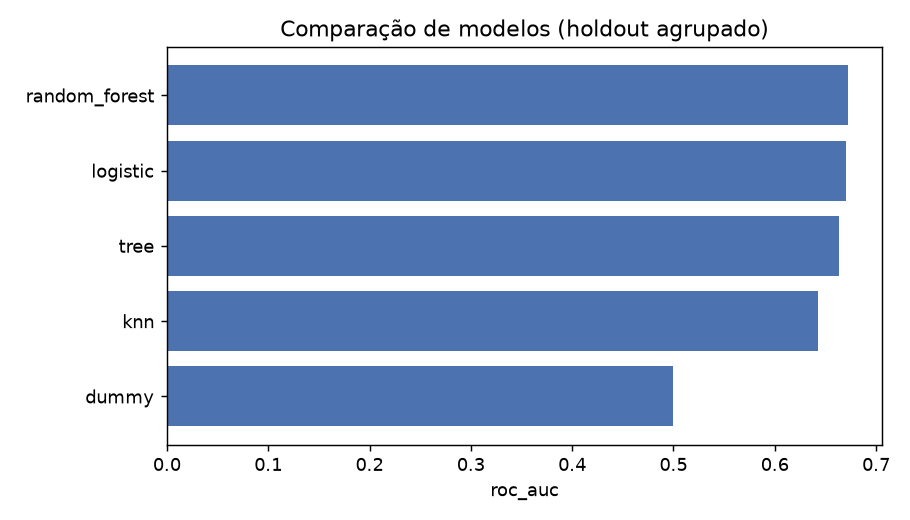

**Curva ROC** — `images/model_roc.png`

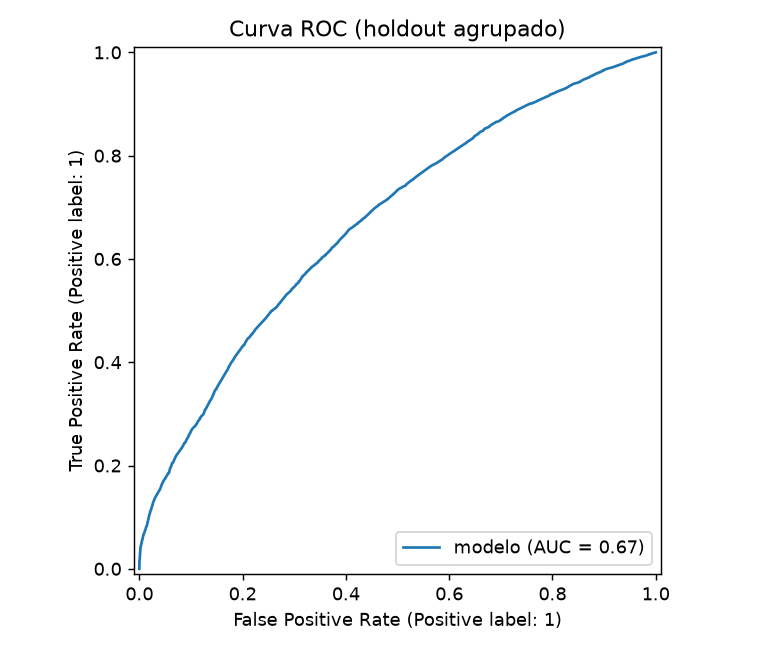

**Curva Precisão-Recall** — `images/model_pr.png`

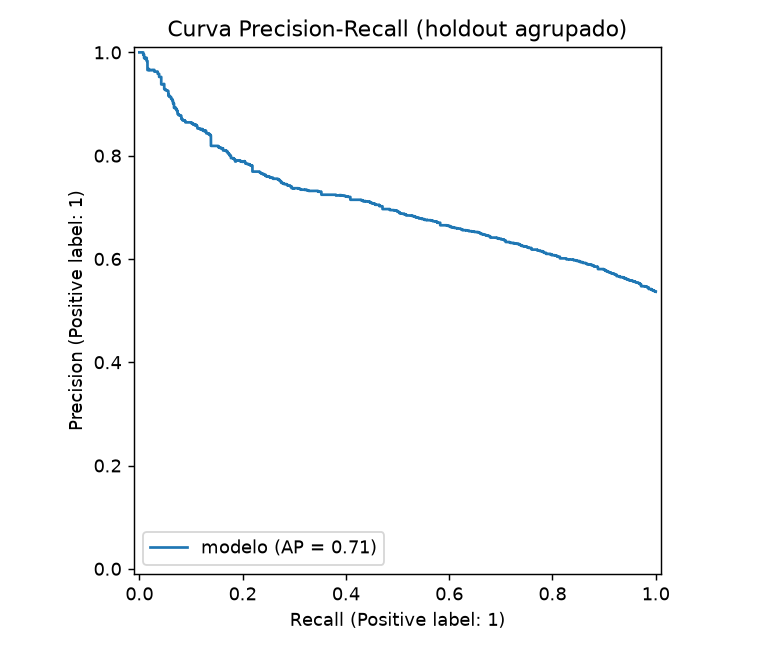

**Matriz de confusão (threshold 0,5)** — `images/model_confusion.png`

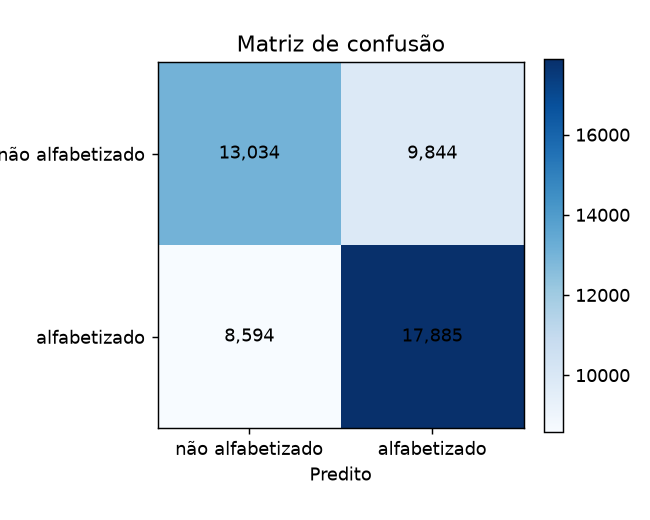

**Calibração** — `images/model_calibration.png`

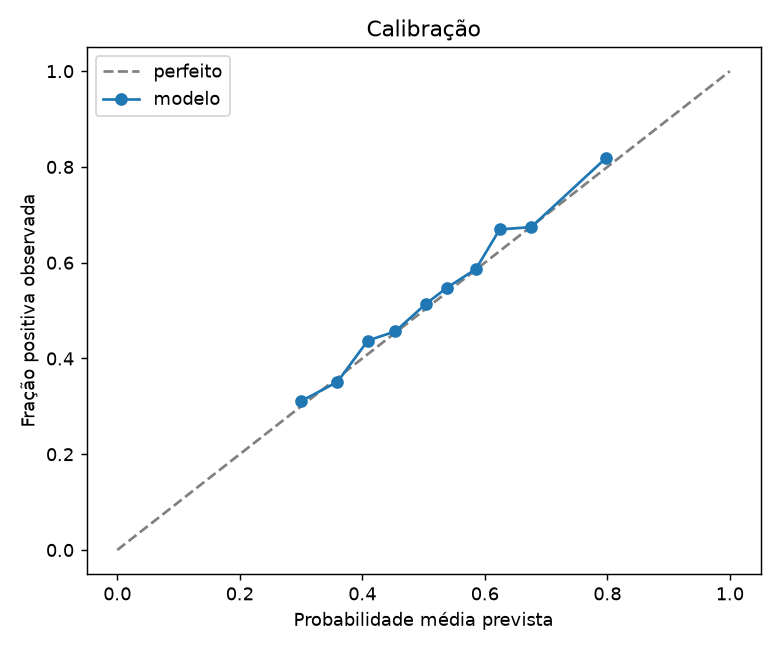

**Curva de aprendizado** — `images/model_learning_curve.png`

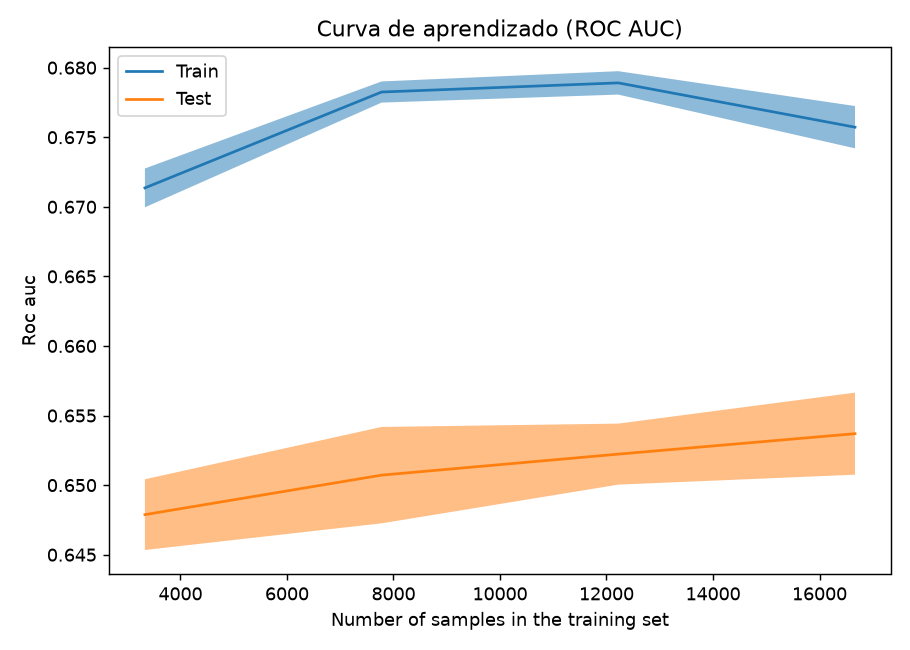

**Data leakage: split aleatório vs agrupado** — `images/model_leakage_compare.png`

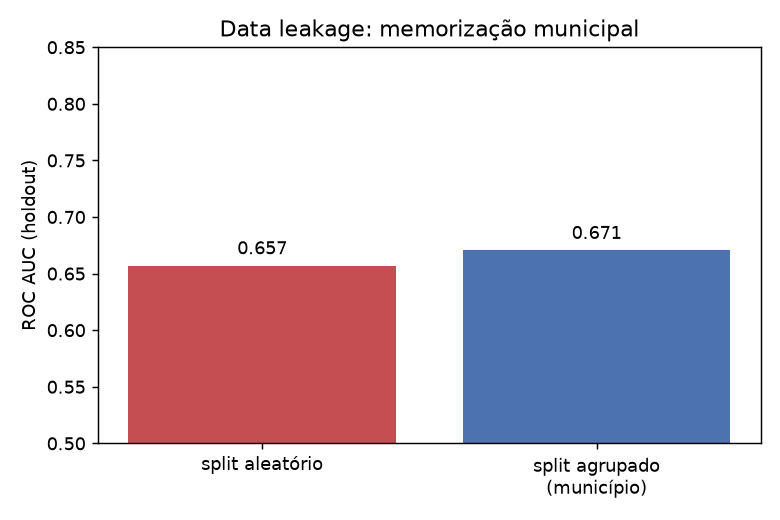

In [6]:
def mostrar(nome, legenda):
    p = ROOT / "images" / nome
    if p.exists():
        display(Markdown(f"**{legenda}** — `images/{nome}`"))
        display(Image(filename=str(p)))
    else:
        print(f"faltando: {nome} (rode scripts/run_modeling.py)")


mostrar("model_compare_auc.png", "Comparação de modelos")
mostrar("model_roc.png", "Curva ROC")
mostrar("model_pr.png", "Curva Precisão-Recall")
mostrar("model_confusion.png", "Matriz de confusão (threshold 0,5)")
mostrar("model_calibration.png", "Calibração")
mostrar("model_learning_curve.png", "Curva de aprendizado")
mostrar("model_leakage_compare.png", "Data leakage: split aleatório vs agrupado")

## Interpretabilidade e aplicação

- Permutation importance, coeficientes/odds, SHAP (`images/model_shap_summary.png`).
- Ranking municipal: `reports/risco_municipal.csv`.
- Relatório técnico: `reports/modelagem.md`.


**Permutation importance (queda de ROC AUC)** — `images/model_permutation_importance.png`

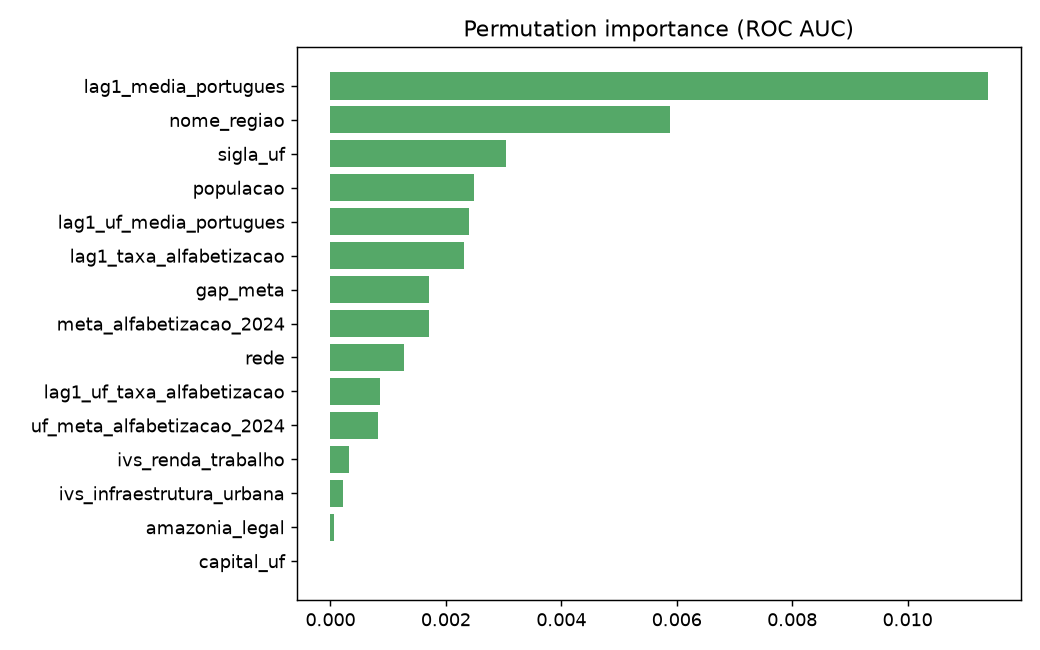

**SHAP — Random Forest** — `images/model_shap_summary.png`

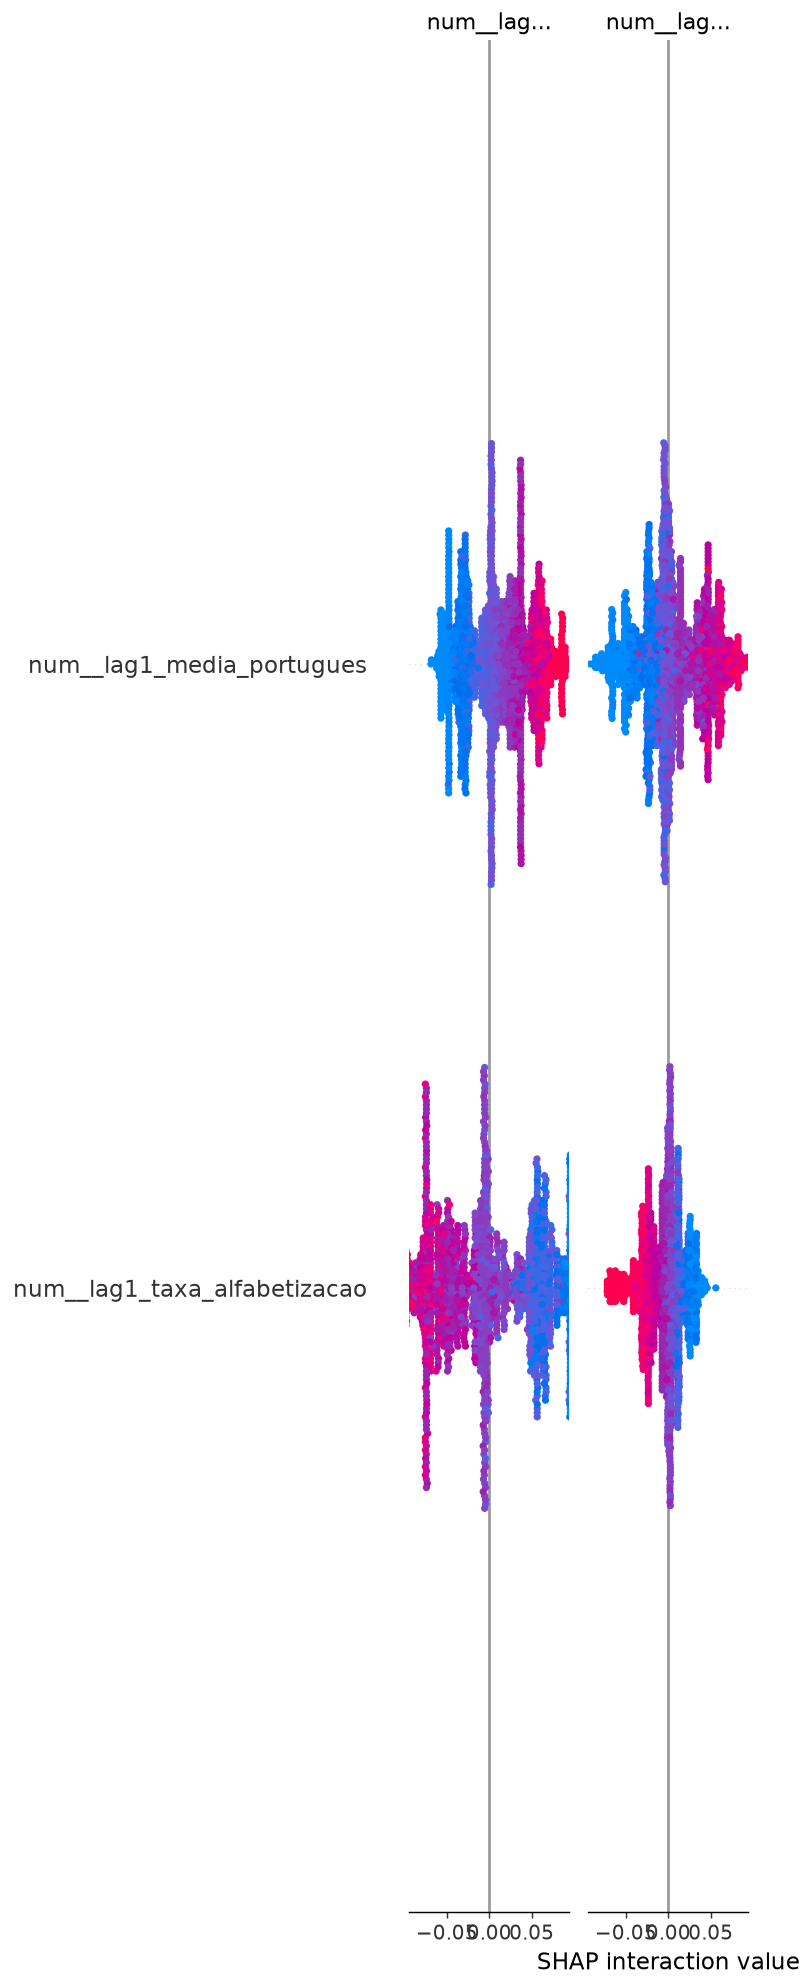

**Regressão logística — |coeficiente|** — `images/model_logistic_coefs.png`

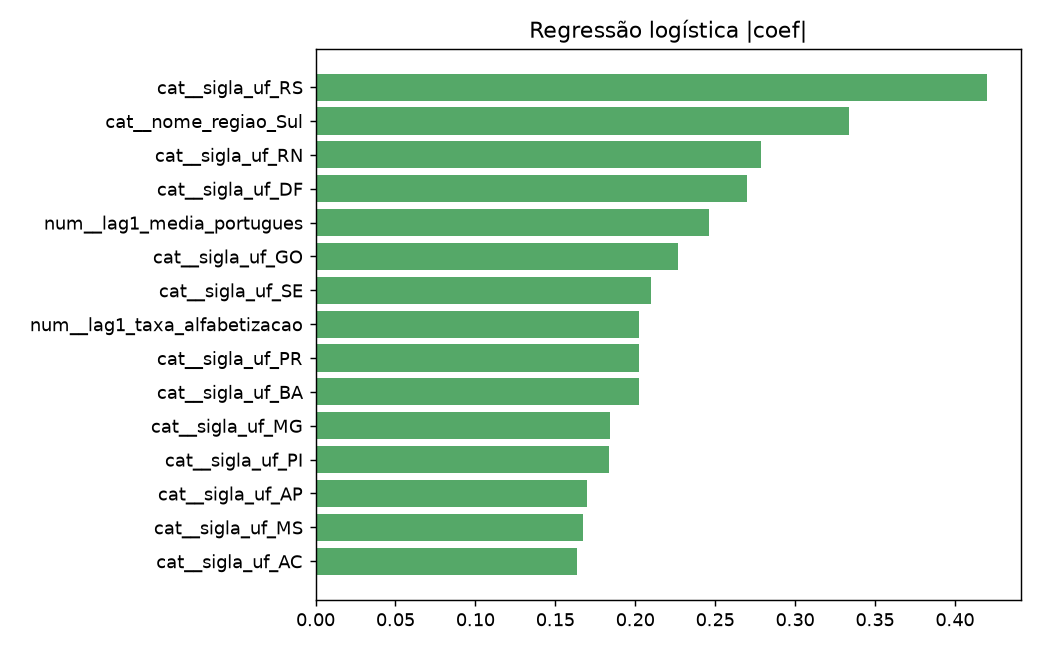

**10 municípios de maior risco previsto (holdout)**

,id_municipio,sigla_uf,nome_regiao,n_alunos,taxa_observada,taxa_prevista,risco,cluster
0,2403509,RN,Nordeste,14,0.357143,0.214560,0.785440,0
1,2907202,BA,Nordeste,80,0.262500,0.233566,0.766434,0
2,2928307,BA,Nordeste,10,0.100000,0.233647,0.766353,0
3,2410108,RN,Nordeste,12,0.166667,0.250264,0.749736,0
4,2805109,SE,Nordeste,12,0.083333,0.253479,0.746521,0
5,2911006,BA,Nordeste,14,0.500000,0.254232,0.745768,0
6,4304630,RS,Sul,128,0.273438,0.257060,0.742940,1
7,2926004,BA,Nordeste,49,0.183673,0.257570,0.742430,0
8,2804706,SE,Nordeste,13,0.846154,0.259763,0.740237,0
9,2401602,RN,Nordeste,9,0.222222,0.261903,0.738097,0


abaixo da meta 2024: 793 de 1099 municípios
abaixo da meta 2025: 918 de 1099 municípios
correlação taxa prevista vs observada por município: 0.6349


In [7]:
mostrar("model_permutation_importance.png", "Permutation importance (queda de ROC AUC)")
mostrar("model_shap_summary.png", "SHAP — Random Forest")
mostrar("model_logistic_coefs.png", "Regressão logística — |coeficiente|")

risco = ROOT / "reports" / "risco_municipal.csv"
if risco.exists():
    df_r = pd.read_csv(risco)
    cols = [c for c in ["id_municipio", "sigla_uf", "nome_regiao", "n_alunos",
                        "taxa_observada", "taxa_prevista", "risco", "cluster"] if c in df_r.columns]
    display(Markdown("**10 municípios de maior risco previsto (holdout)**"))
    display(df_r[cols].head(10))
    for ano in (2024, 2025):
        col = f"risco_nao_atingir_meta_{ano}"
        if col in df_r.columns:
            print(f"abaixo da meta {ano}: {int(df_r[col].sum())} de {len(df_r)} municípios")
    print("correlação taxa prevista vs observada por município:",
          round(df_r["taxa_prevista"].corr(df_r["taxa_observada"]), 4))


## Quais regiões possuem padrões semelhantes?

O ranking de risco responde *quem* está pior, não *quem se parece com quem*. Para isso agrupamos os municípios do holdout com **KMeans** sobre o perfil educacional e socioeconômico (`taxa_prevista`, `lag1_taxa_alfabetizacao`, `lag1_media_portugues`, `ivs`, `pib_per_capita`, `populacao`), padronizado, com `k` escolhido por *silhouette*.

Nenhuma variável geográfica entra no agrupamento — logo, se um cluster concentra municípios de uma mesma região, isso é **resultado** e não consequência do desenho.

diagnóstico do agrupamento: {'features': ['taxa_prevista', 'lag1_taxa_alfabetizacao', 'lag1_media_portugues', 'ivs', 'pib_per_capita', 'populacao'], 'k_escolhido': 3, 'silhouette_por_k': {'3': 0.2451, '4': 0.2353, '5': 0.205, '6': 0.2122}, 'silhouette': 0.2451}


**Perfil médio de cada cluster**

,cluster,n_municipios,taxa_prevista,lag1_taxa_alfabetizacao,lag1_media_portugues,ivs,pib_per_capita,populacao,regiao_predominante,share_regiao_predominante
0,0,330,0.414,41.120,729.021,0.438,18563.286,29094.164,Nordeste,0.652
1,1,439,0.538,61.230,749.640,0.239,64624.034,45962.408,Sul,0.387
2,2,330,0.715,81.006,777.724,0.352,26979.594,13778.385,Nordeste,0.361


**Distribuição dos clusters dentro de cada região** (linha soma 1)

,nome_regiao,cluster_0,cluster_1,cluster_2
0,Centro-Oeste,0.069,0.588,0.343
1,Nordeste,0.614,0.046,0.340
2,Norte,0.693,0.228,0.079
3,Sudeste,0.104,0.550,0.346
4,Sul,0.025,0.717,0.257


**Clusters de municípios e composição regional** — `images/model_clusters.png`

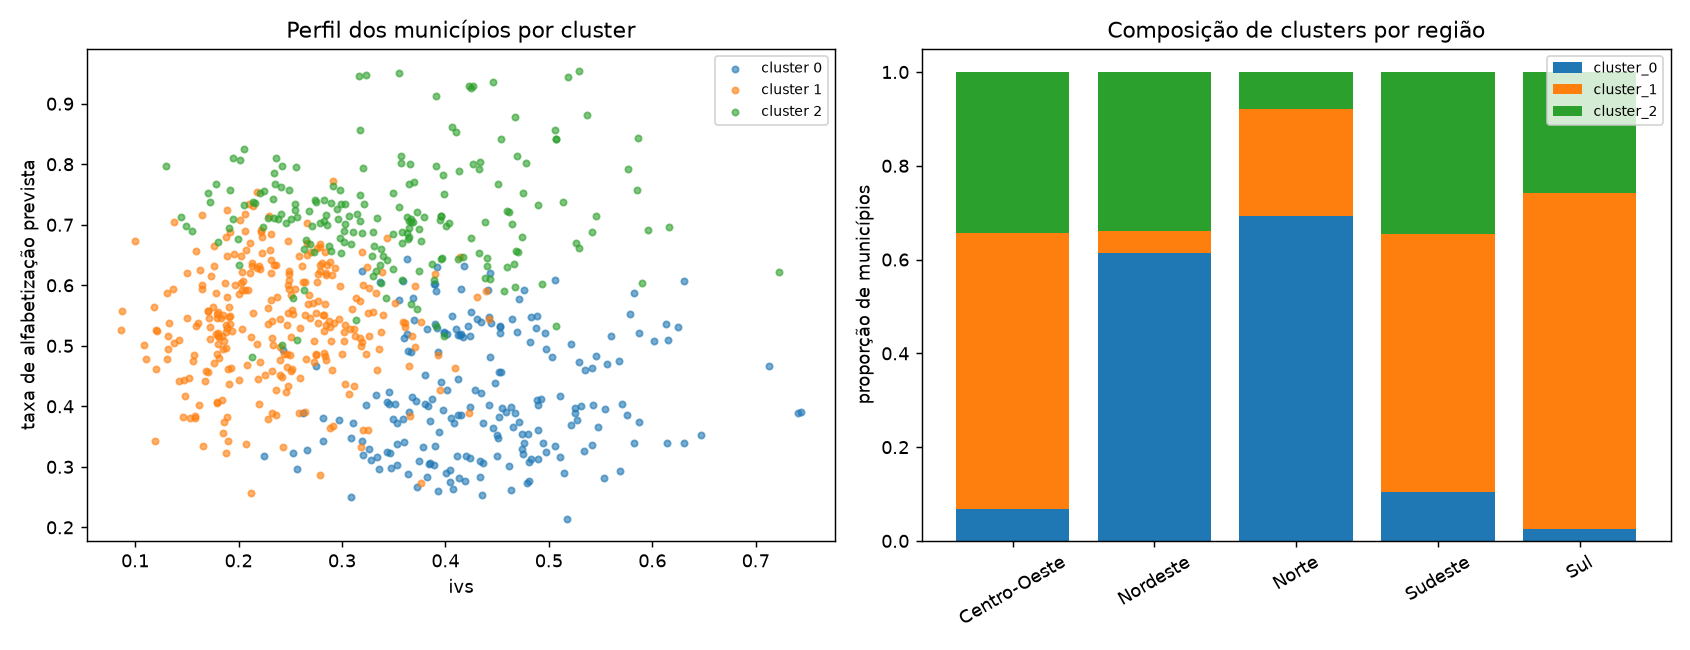

In [8]:
if metrics_path.exists():
    print("diagnóstico do agrupamento:", metrics.get("clusters"))

perfil = ROOT / "reports" / "clusters_perfil.csv"
if perfil.exists():
    display(Markdown("**Perfil médio de cada cluster**"))
    display(pd.read_csv(perfil).round(3))

por_regiao = ROOT / "reports" / "clusters_por_regiao.csv"
if por_regiao.exists():
    display(Markdown("**Distribuição dos clusters dentro de cada região** (linha soma 1)"))
    display(pd.read_csv(por_regiao).round(3))

mostrar("model_clusters.png", "Clusters de municípios e composição regional")